In [1]:
import json

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

In [39]:
NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO = 1
NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO = 1
NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO = 1
NUM_CONFIGS_TO_EXTRAPOLATE_TO = 10**2

DATASET_BLACKLIST = []

In [13]:
dfs = {}
d_datasets = set()

for k in [
    "lcdb.workflow.sklearn.KNNWorkflow",
    "lcdb.workflow.sklearn.LibLinearWorkflow",
    "lcdb.workflow.sklearn.LibSVMWorkflow",
    "lcdb.workflow.sklearn.TreesEnsembleWorkflow",
    #"lcdb.workflow.xgboost.XGBoostWorkflow"
]:
    dfs[k] = pd.read_csv(f"data/{k}.csv")
    dfs[k] = dfs[k][~dfs[k]["m:openmlid"].isin(DATASET_BLACKLIST)]
    dfs[k]["runtimes"] = dfs[k]["runtimes"].apply(lambda r: json.loads(r) if type(r) == str else None)
    d_datasets |= set(pd.unique(dfs[k]["m:openmlid"]))

In [34]:
d_datasets = sorted(d_datasets)
d_workflows = sorted(dfs.keys())

In [35]:
total_runtimes_in_s = np.zeros((len(d_workflows), len(d_datasets)))
num_datapoints = np.zeros((len(d_workflows), len(d_datasets)))
max_memory_requirements = np.zeros((len(d_workflows), len(d_datasets)))
for i, workflow in enumerate(d_workflows):
    for j, openmlid in enumerate(d_datasets):
        df_detail = dfs[workflow][dfs[workflow]["m:openmlid"] == openmlid]
        if len(df_detail) == 0:
            total_runtimes_in_s[i, j] = np.nan
            max_memory_requirements[i, j] = np.nan
            num_datapoints[i, j] = 0
        else:
            num_datapoints[i, j] = len(df_detail)
            total_runtimes_in_s[i, j] = (df_detail["m:timestamp_end"] - df_detail["m:timestamp_start"]).sum()
mean_walltime_per_config_in_s = total_runtimes_in_s / np.maximum(1, num_datapoints)

display(pd.DataFrame({
    "dataset:": d_datasets,
    "total walltime in h": ((total_runtimes_in_s[0] / 3600).astype(int)),
    "num_points": num_datapoints[0],
    "mean walltime per config in s": ((mean_walltime_per_config_in_s[0]).astype(int)),
}))

print(f"Total consumed walltime (hours) for the underlying data by workflow ({total_runtimes_in_s.sum() / 3600:.1f} in total):")
for workflow, runtimes_on_datasets, avg_runtime_per_config_for_workflow, datapoints_for_workflow in zip(d_workflows, total_runtimes_in_s, mean_walltime_per_config_in_s, num_datapoints):
    print(f"\t{workflow}: {np.nansum(runtimes_on_datasets) / 3600:.1f}h (for {int(datapoints_for_workflow.sum())} observations. This is an avg runtime of {avg_runtime_per_config_for_workflow.sum() / 3600:.1f}h per config)")

,dataset:,total walltime in h,num_points,mean walltime per config in s
0,3,0,100.0,18
1,12,1,100.0,47
2,23,0,100.0,0
3,31,0,100.0,0
4,54,0,100.0,2
...,...,...,...,...
66,42734,8,100.0,296
67,42742,13,100.0,490
68,42746,0,100.0,2
69,42769,67,100.0,2444


Total consumed walltime (hours) for the underlying data by workflow (1961.0 in total):
	lcdb.workflow.sklearn.KNNWorkflow: 485.1h (for 7100 observations. This is an avg runtime of 4.9h per config)
	lcdb.workflow.sklearn.LibLinearWorkflow: 185.3h (for 7100 observations. This is an avg runtime of 1.9h per config)
	lcdb.workflow.sklearn.LibSVMWorkflow: 504.0h (for 7100 observations. This is an avg runtime of 5.0h per config)
	lcdb.workflow.sklearn.TreesEnsembleWorkflow: 786.6h (for 7100 observations. This is an avg runtime of 7.9h per config)


# Extrapolate Compute
We extrapolate
$$\begin{align*}
    \mathbb{E}[\text{runtime on first c configs with first s seed combinations}] &= \mathbb{E}\left[\sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\text{ runtime of first c configs of workflow on }\mathit{D}\text{ and seed combination}\right]\\
    &= \sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and seed combination}\right]\\
    &\approx |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]\\
    &\approx c\cdot |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{any config of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]
\end{align*}
$$
Here we assume that the expected runtime is the same for all configs and seeds, which is the case if we do not condition on specific such configs and seeds.

This motivates to create a matrix with estimates of mean runtimes, which would be the estimates of the $\mathbb{E}$ in the sum.

Overall expected walltime for 1 test seeds, 1 validation seeds, 1 workflow seeds, and 100 configs overall is 2.0 thsd hours
	Overall expected walltime for lcdb.workflow.sklearn.KNNWorkflow is 0.5 thsd hours
	Overall expected walltime for lcdb.workflow.sklearn.LibLinearWorkflow is 0.2 thsd hours
	Overall expected walltime for lcdb.workflow.sklearn.LibSVMWorkflow is 0.5 thsd hours
	Overall expected walltime for lcdb.workflow.sklearn.TreesEnsembleWorkflow is 0.8 thsd hours


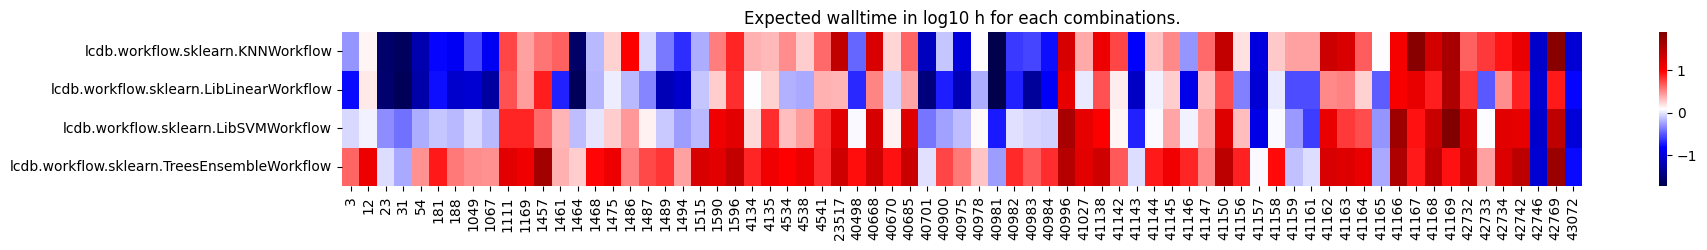

In [41]:
total_expected_entries = NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO * NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO * NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO * NUM_CONFIGS_TO_EXTRAPOLATE_TO

fig, ax = plt.subplots(1, 1, figsize=(20, 2))

# show data availability
mean_walltime_per_config_in_s = total_runtimes_in_s / np.maximum(1, num_datapoints)
expected_overall_runtimes_in_h = (mean_walltime_per_config_in_s * total_expected_entries) / 3600
sb.heatmap(np.log10(expected_overall_runtimes_in_h), ax=ax, cmap="seismic")
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Expected walltime in log10 h for each combinations.")

print(f"Overall expected walltime for {NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO} test seeds, {NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO} validation seeds, {NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO} workflow seeds, and {NUM_CONFIGS_TO_EXTRAPOLATE_TO} configs overall is {np.round(np.sum(expected_overall_runtimes_in_h) / 10**3, 1)} thsd hours")
for i, workflow in enumerate(d_workflows):
    print(f"\tOverall expected walltime for {workflow} is {np.round(np.sum(expected_overall_runtimes_in_h[i]) / 10**3, 1)} thsd hours")

# SBU Extrapolation
The above numbers are in CPU hours, but we here assume that a certain number of CPUs must be blocked for each dataset/workflow combination since always a full node is being reserved. Therefore, the number of required SBUs will be higher.

In [42]:
class MemoryBinRetriever:

    def __init__(self):
        self.df = pd.read_csv("data/memory_analysis/memory_bins_all_workflows.csv")
        self.df["datasets"] = [json.loads(d) if type(d) == str else [] for d in self.df["datasets"]]
    
    def get_memory_bin_for_workflow_dataset_combination(self, workflow, dataset):
        df_base = self.df[self.df["m:workflow"] == workflow]
        df_base = df_base[[dataset in row["datasets"] for _, row in df_base.iterrows()]]
        assert len(df_base) >= 1, f"Didn't find a memory configuration for openmlid {dataset} with workflow {workflow}"
        assert len(df_base) <= 1, f"Memory configuration for openmlid {dataset} with workflow {workflow} is ambiguous"
        return float(df_base["memory_bin_gb"].iloc[0][1:])

    def get_memory_bin_matrix(self, workflows, datasets):
        memory_bin_matrix = np.zeros((len(workflows), len(datasets)))
        for i, workflow in enumerate(workflows):
            for j, dataset in enumerate(datasets):
                memory_bin_matrix[i, j] = self.get_memory_bin_for_workflow_dataset_combination(workflow, dataset)
        return memory_bin_matrix

retriever = MemoryBinRetriever()
memory_bin_matrix = retriever.get_memory_bin_matrix(d_workflows, d_datasets)

Overall expected node hours for 1 test seeds, 1 validation seeds, 1 workflow seeds, and 100 configs overall is 2.0 thsd hours
	Overall expected node hours for lcdb.workflow.sklearn.KNNWorkflow is 71.0 k hours
	Overall expected node hours for lcdb.workflow.sklearn.LibLinearWorkflow is 71.0 k hours
	Overall expected node hours for lcdb.workflow.sklearn.LibSVMWorkflow is 72.0 k hours
	Overall expected node hours for lcdb.workflow.sklearn.TreesEnsembleWorkflow is 71.0 k hours


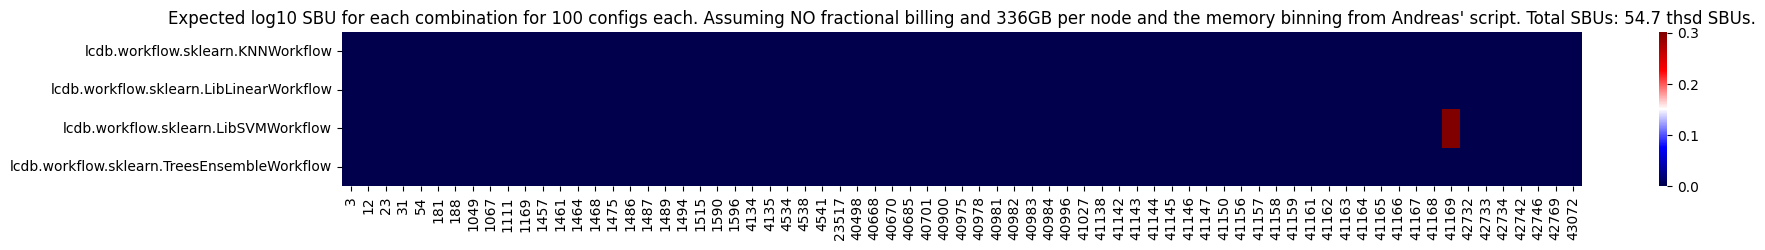

Overall expected node hours for 1 test seeds, 1 validation seeds, 1 workflow seeds, and 100 configs overall is 2.0 thsd hours
	Overall expected node hours for lcdb.workflow.sklearn.KNNWorkflow is 5.8 k hours
	Overall expected node hours for lcdb.workflow.sklearn.LibLinearWorkflow is 2.4 k hours
	Overall expected node hours for lcdb.workflow.sklearn.LibSVMWorkflow is 6.8 k hours
	Overall expected node hours for lcdb.workflow.sklearn.TreesEnsembleWorkflow is 9.9 k hours


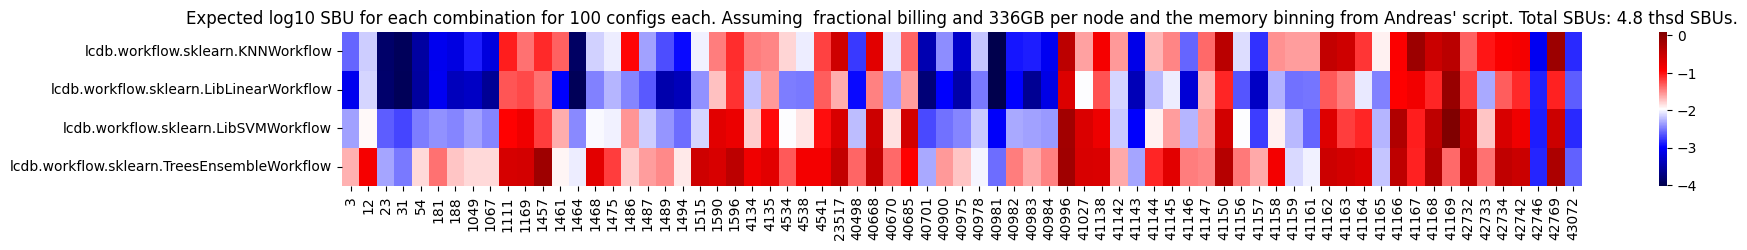

In [43]:
max_memory_per_node_in_gb = 336
sbus_per_node_hours = 192

parallel_jobs_per_combo = max_memory_per_node_in_gb / memory_bin_matrix
for fractional_billing in [False, True]:
    required_node_hours = expected_overall_runtimes_in_h / parallel_jobs_per_combo
    if not fractional_billing:
        required_node_hours = np.ceil(required_node_hours)
    sbus_overall = sbus_per_node_hours * required_node_hours.sum(axis=1)

    print(f"Overall expected node hours for {NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO} test seeds, {NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO} validation seeds, {NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO} workflow seeds, and {NUM_CONFIGS_TO_EXTRAPOLATE_TO} configs overall is {np.round(np.sum(expected_overall_runtimes_in_h) / 10**3, 1)} thsd hours")
    for i, workflow in enumerate(d_workflows):
        print(f"\tOverall expected node hours for {workflow} is {np.round(np.sum(required_node_hours[i]), 1)} k hours")


    fig, ax = plt.subplots(1, 1, figsize=(20, 2))
    sb.heatmap(np.log10(required_node_hours), ax=ax, cmap="seismic")
    ax.set_xticklabels(d_datasets, rotation=90)
    ax.set_yticklabels(d_workflows, rotation=0)
    ax.set_title(f"Expected log10 SBU for each combination for {NUM_CONFIGS_TO_EXTRAPOLATE_TO} configs each. Assuming {'' if fractional_billing else 'NO'} fractional billing and {max_memory_per_node_in_gb}GB per node and the memory binning from Andreas' script. Total SBUs: {np.round(sbus_overall.sum() / 10**3, 1)} thsd SBUs.")  
    plt.show()